# Metrics

In [41]:
#import libraries
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

#scikit 
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import accuracy_score, balanced_accuracy_score,confusion_matrix, classification_report, auc, roc_curve, roc_auc_score


In [2]:
#load the dataset

data = pd.read_csv("customer_churn_dataset-training-master.csv")
data[:5]

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [3]:
#check shape

data.shape

(440833, 12)

In [4]:
#data type
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB


In [5]:
# check the null values

data.isna().sum()

CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

In [6]:
#fic null values
data.dropna(inplace=True)

#confirm
data.isna().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

In [7]:
#check duplicates

data.duplicated().sum()

np.int64(0)

In [8]:
#select cat colns

cat_coln = data.select_dtypes('object')
cat_coln

,Gender,Subscription Type,Contract Length
0,Female,Standard,Annual
1,Female,Basic,Monthly
2,Female,Basic,Quarterly
3,Male,Standard,Monthly
4,Male,Basic,Monthly
...,...,...,...
440828,Male,Premium,Annual
440829,Female,Premium,Annual
440830,Male,Standard,Quarterly
440831,Male,Standard,Quarterly


In [9]:
#OHE
ohe = pd.get_dummies(cat_coln, drop_first= True, dtype='int')
ohe

,Gender_Male,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Monthly,Contract Length_Quarterly
0,0,0,1,0,0
1,0,0,0,1,0
2,0,0,0,0,1
3,1,0,1,1,0
4,1,0,0,1,0
...,...,...,...,...,...
440828,1,1,0,0,0
440829,0,1,0,0,0
440830,1,0,1,0,1
440831,1,0,1,0,1


In [10]:
#concat/merge

merged_df = pd.concat([data, ohe], axis=1)
merged_df[:5]

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn,Gender_Male,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Monthly,Contract Length_Quarterly
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0,0,0,1,0,0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0,0,0,0,1,0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0,0,0,0,0,1
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0,1,0,1,1,0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0,1,0,0,1,0


In [11]:
#remove the encoded columns

merged_df.drop(cat_coln, axis=1, inplace=True)
merged_df

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Gender_Male,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Monthly,Contract Length_Quarterly
0,2.0,30.0,39.0,14.0,5.0,18.0,932.00,17.0,1.0,0,0,1,0,0
1,3.0,65.0,49.0,1.0,10.0,8.0,557.00,6.0,1.0,0,0,0,1,0
2,4.0,55.0,14.0,4.0,6.0,18.0,185.00,3.0,1.0,0,0,0,0,1
3,5.0,58.0,38.0,21.0,7.0,7.0,396.00,29.0,1.0,1,0,1,1,0
4,6.0,23.0,32.0,20.0,5.0,8.0,617.00,20.0,1.0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
440828,449995.0,42.0,54.0,15.0,1.0,3.0,716.38,8.0,0.0,1,1,0,0,0
440829,449996.0,25.0,8.0,13.0,1.0,20.0,745.38,2.0,0.0,0,1,0,0,0
440830,449997.0,26.0,35.0,27.0,1.0,5.0,977.31,9.0,0.0,1,0,1,0,1
440831,449998.0,28.0,55.0,14.0,2.0,0.0,602.55,2.0,0.0,1,0,1,0,1


In [12]:
#drop customer id

del merged_df["CustomerID"]

#convert churn to int

merged_df["Churn"] = merged_df["Churn"].astype(int)

merged_df

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Gender_Male,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Monthly,Contract Length_Quarterly
0,30.0,39.0,14.0,5.0,18.0,932.00,17.0,1,0,0,1,0,0
1,65.0,49.0,1.0,10.0,8.0,557.00,6.0,1,0,0,0,1,0
2,55.0,14.0,4.0,6.0,18.0,185.00,3.0,1,0,0,0,0,1
3,58.0,38.0,21.0,7.0,7.0,396.00,29.0,1,1,0,1,1,0
4,23.0,32.0,20.0,5.0,8.0,617.00,20.0,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
440828,42.0,54.0,15.0,1.0,3.0,716.38,8.0,0,1,1,0,0,0
440829,25.0,8.0,13.0,1.0,20.0,745.38,2.0,0,0,1,0,0,0
440830,26.0,35.0,27.0,1.0,5.0,977.31,9.0,0,1,0,1,0,1
440831,28.0,55.0,14.0,2.0,0.0,602.55,2.0,0,1,0,1,0,1


In [13]:
#save new dataset

merged_df.to_csv("churn.csv", index=None)

In [14]:
#seperate label from features

X = merged_df.drop("Churn", axis=1)
y = merged_df['Churn']
X

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Gender_Male,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Monthly,Contract Length_Quarterly
0,30.0,39.0,14.0,5.0,18.0,932.00,17.0,0,0,1,0,0
1,65.0,49.0,1.0,10.0,8.0,557.00,6.0,0,0,0,1,0
2,55.0,14.0,4.0,6.0,18.0,185.00,3.0,0,0,0,0,1
3,58.0,38.0,21.0,7.0,7.0,396.00,29.0,1,0,1,1,0
4,23.0,32.0,20.0,5.0,8.0,617.00,20.0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
440828,42.0,54.0,15.0,1.0,3.0,716.38,8.0,1,1,0,0,0
440829,25.0,8.0,13.0,1.0,20.0,745.38,2.0,0,1,0,0,0
440830,26.0,35.0,27.0,1.0,5.0,977.31,9.0,1,0,1,0,1
440831,28.0,55.0,14.0,2.0,0.0,602.55,2.0,1,0,1,0,1


In [15]:
#splitdata into train ans test set
x_train, x_test, y_train, y_test = train_test_split(X,y, test_size=.2, random_state=42)

In [16]:
#scale

sc = StandardScaler()

x_train_s = sc.fit_transform(x_train)
x_test_s = sc.transform(x_test)


In [17]:
##model1
model1 =LogisticRegression(max_iter=100)

model1.fit(x_train_s, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [18]:
#check score on the training set
model1.score(x_train_s, y_train)

0.8951072547601832

In [19]:
#check overfitting using learning curve
train_sizes, train_scores, test_scores =learning_curve(model1, x_train_s,y_train,train_sizes=np.linspace(0.1, 1.0, 10), cv=5)

In [24]:
#get the mean scores

train_score_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

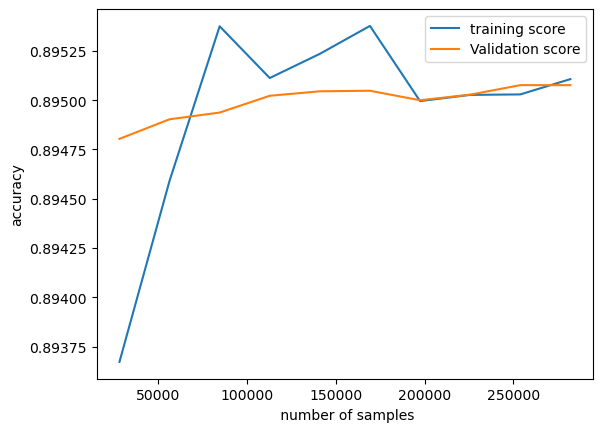

In [37]:
#plot
plt.plot(train_sizes, train_score_mean, label= "training score")
plt.plot(train_sizes, test_scores_mean, label= "Validation score")

plt.xlabel(" number of samples")
plt.ylabel("accuracy")
plt.legend();

In [34]:
#prediction

y_pred = model1.predict(x_test_s)

#confirm

pd.DataFrame({"actual": y_test, "predicted":y_pred})[:5]

,actual,predicted
159565,1,1
127464,1,1
22398,1,0
99337,1,1
300997,0,0


In [36]:
#check the accuracy
accuracy_score(y_test, y_pred)

0.8964465162702598

In [39]:
#confusiin matrix

cm = confusion_matrix(y_test, y_pred)
cm

array([[34558,  3505],
       [ 5625, 44479]])

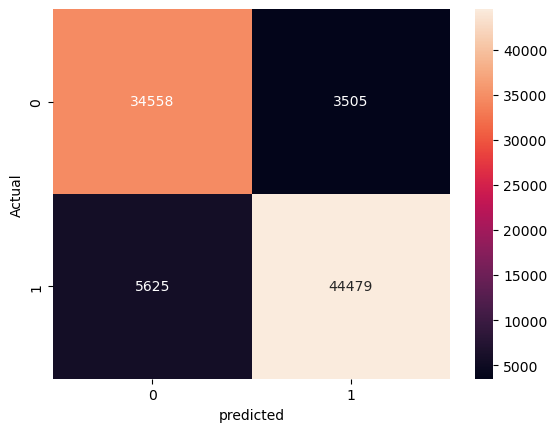

In [45]:
#visualize

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("predicted")
plt.ylabel("Actual");

In [46]:
#confusiin matrix in percentage

cmp = confusion_matrix(y_test, y_pred, normalize='true')
cmp

array([[0.90791582, 0.09208418],
       [0.11226649, 0.88773351]])

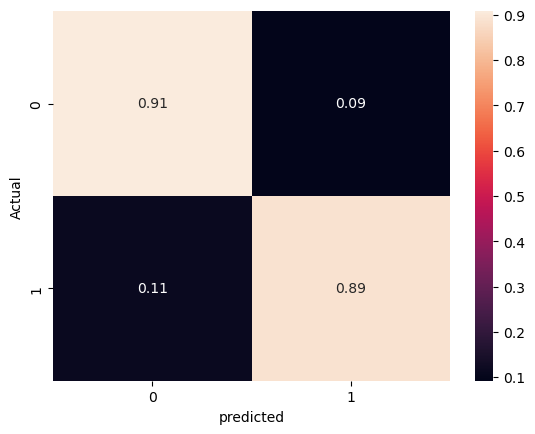

In [48]:
#visualize

sns.heatmap(cmp, annot=True, fmt=".2f")
plt.xlabel("predicted")
plt.ylabel("Actual");

In [50]:
#Get classification report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.91      0.88     38063
           1       0.93      0.89      0.91     50104

    accuracy                           0.90     88167
   macro avg       0.89      0.90      0.90     88167
weighted avg       0.90      0.90      0.90     88167



In [63]:
#check AUC (apply on binary classification)
y_pred_pro = model1.predict_proba(x_test_s)[:,1]

In [64]:
roc_auc_score(y_test, y_pred_pro)

0.9597064367838879

In [66]:
#getting false positive rate and tree positive rate
fpr, tpr,threshold = roc_curve(y_test, y_pred_pro)

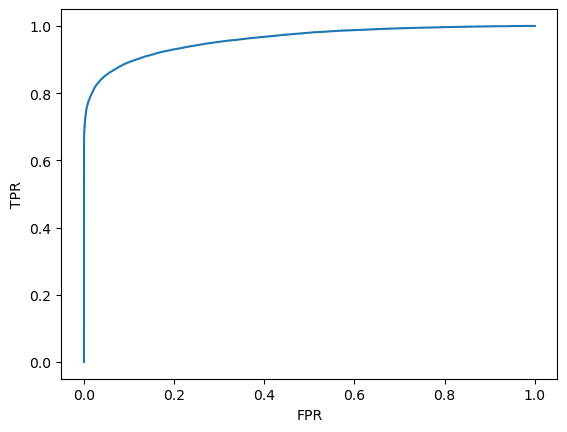

In [68]:
#plot
plt.plot(fpr, tpr)
plt.ylabel("TPR")
plt.xlabel("FPR");

In [71]:
#for class imbalance use balanced accuracy

balanced_accuracy_score(y_test, y_pred)

0.8978246690280691

### Handling Class imbalance



In [74]:
#check the classes values
y_train.value_counts()

Churn
1    199895
0    152770
Name: count, dtype: int64

In [76]:
#package used to handle class imbalance

from imblearn.over_sampling import SMOTE # sythenthic minority oversampling technique

sm = SMOTE(random_state=42)

x_train_res, y_train_res = sm.fit_resample(x_train, y_train)

In [78]:
y_train_res.value_counts()

Churn
0    199895
1    199895
Name: count, dtype: int64